# <center> Data Science in Healthcare : Breast Cancer Detection <center/>
<center> <b>DLBDSME01<b/> - Model Engineering <center/>
<center> IU International University of Applied Sciences <center/>

## Objective :
Greetings, in this project, our goal is to help our local oncologists address the interpretability challenges of these systems by developing a transparent ML model capable of classifying tumors as Malignant or Benign while ensuring explainability in decision-making. Finally, we're proposing an integration strategy to support daily diagnostics.
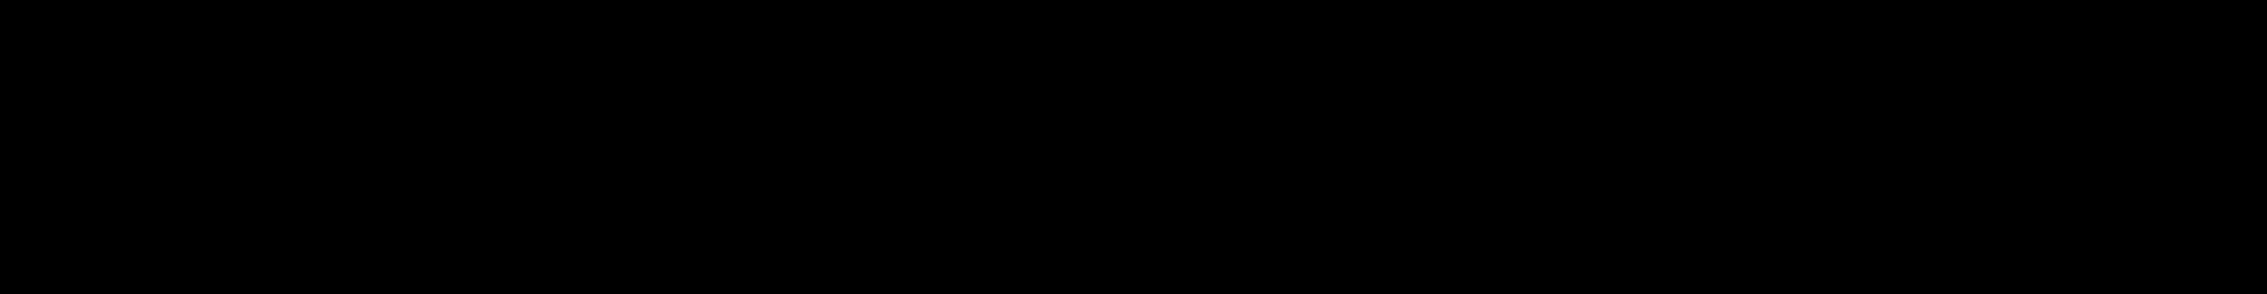
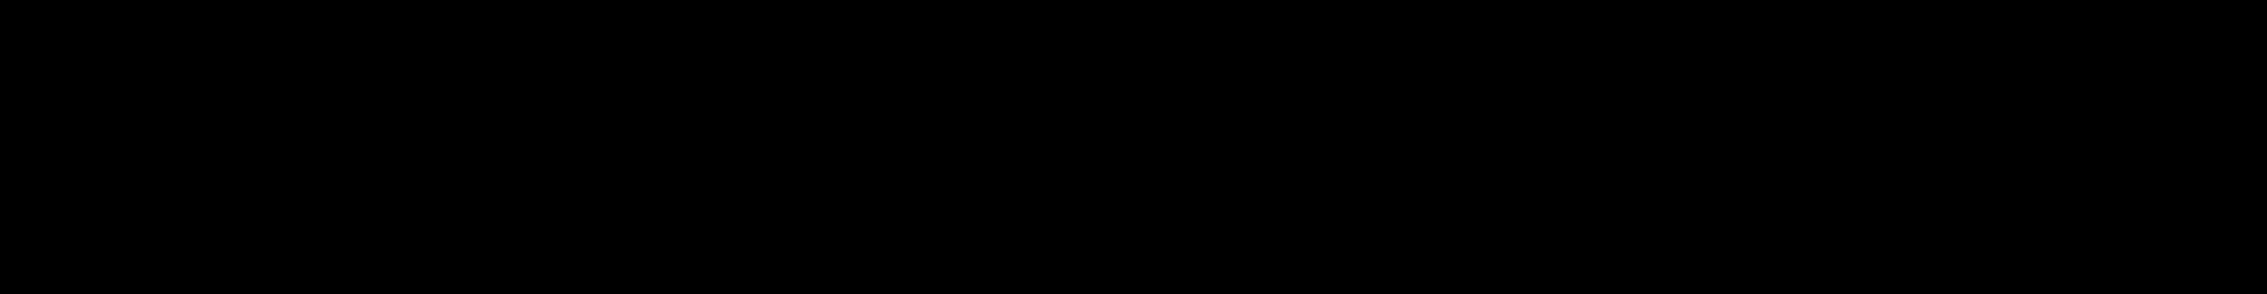
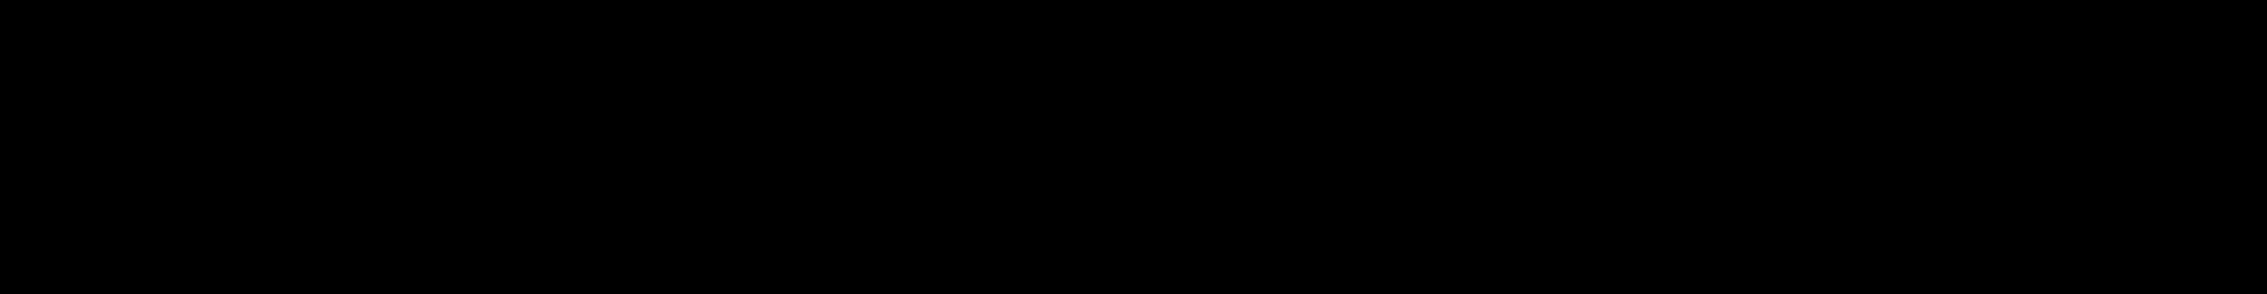
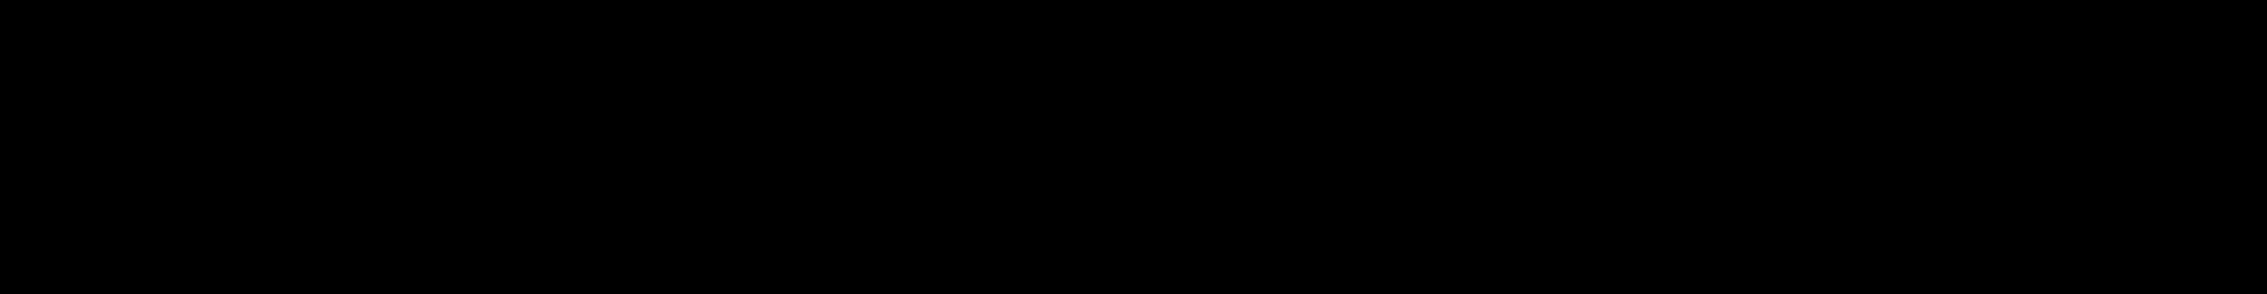

## List of contents :
1. About the dataset
2. Exploratory Data Analysis
3. Data Preparation
4. Modeling
5. Deployment
6. Monitoring
7. Summary

Start with importing the required libraries :

In [17]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import warnings
import mlflow

# Avoid unnecessary warnings
warnings.filterwarnings("ignore")

### 1. About the dataset
The data we're operating on in this project is **Breast Cancer Wisconsin (Diagnostic)**, donated on *10/31/1995*, provided in .csv format available from [here](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). **Each row in this dataset represents a single tumor sample from one patient**. Specifically, the data in a single row is the mathematical breakdown of a digitized image of a Fine Needle Aspirate (FNA) test—a clinical procedure where a small sample of cells is extracted from a breast mass. The algorithm that created this dataset looked at the cell nuclei in that image and calculated specific measurements to describe their size, shape, and texture.

#### The "Rule of 3" (How 10 traits become 30 features)

Instead of just 10 columns, the dataset has 30 numeric feature columns. This is because for every single clinical trait, the dataset records three different statistical calculations:

1. **Mean:** The average value of that trait across all the cells in the image.
2. **Standard Error (SE):** How much that trait varies among the cells in the sample.
3. **Worst (Largest):** The average of the three largest values found in the image. (This is highly useful because cancerous cells often exhibit extreme, irregular shapes).

#### The 10 Core Biological Traits

Every feature in this dataset is a variation (Mean, SE, or Worst) of these 10 core measurements of the cell nuclei:

1. **Radius:** The distance from the center of the nucleus to its outer edge.
2. **Texture:** The standard deviation of the grayscale values in the image. (Malignant cells often have a rougher, more irregular visual texture).
3. **Perimeter:** The total distance around the core of the nucleus.
4. **Area:** The total size of the nucleus. *(Note: Radius, Perimeter, and Area are the ones heavily correlated in your heatmap).*
5. **Smoothness:** Measures local variations in the radius lengths. It indicates if the edge of the nucleus is perfectly smooth or jagged.
6. **Compactness:** A mathematical ratio comparing the perimeter to the area ($Perimeter^2 / Area - 1.0$).
7. **Concavity:** The severity of "dents" or concave portions on the outline of the nucleus.
8. **Concave Points:** The actual *number* of those dents on the contour of the nucleus. Malignant cells are rarely perfectly round.
9. **Symmetry:** How symmetrical the cell nucleus is.
10. **Fractal Dimension:** A complex metric measuring the "coastline approximation." Essentially, it measures the complexity of the cell's boundary.

### The Final DataFrame Structure

When you put it all together, a single row in your Pandas DataFrame looks like this:

* `ID Number`: The patient/sample identifier (usually dropped before training).
* `Diagnosis`: The Target variable (`M` = Malignant, `B` = Benign).
* `radius_mean`, `texture_mean`, ... (10 features)
* `radius_se`, `texture_se`, ... (10 features)
* `radius_worst`, `texture_worst`, ... (10 features)

Let's start by loading the data

In [2]:
# Formulating the directory
path = Path.cwd().parent

# Loading the data
data = pd.read_csv(f'{path}/data/Data for Task 1.csv')

# Display a sample of the data
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Next, we head inspect the data for mixed data types, inconsistencies, or null values.

In [3]:
# Displaying the data's description
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The result of the inspection was as follows :
* Data Completeness: There are 0 missing values across all 569 records
* Data Consistency: All 30 features (radius, texture, etc.) are stored as float64 (decimal numbers).
* Target Format: The diagnosis is currently a categorical "object" (B or M). We will need to encode this numerically later.

### 2. Exploratory Data Analysis
At this phase, we start to explore the data to gain insights into the distribution of the features and the target variable.


#### 2.1. The Target variable
The "diagnosis" variable is the the feature we're intending to predict at the end of our modelling.

Class Counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


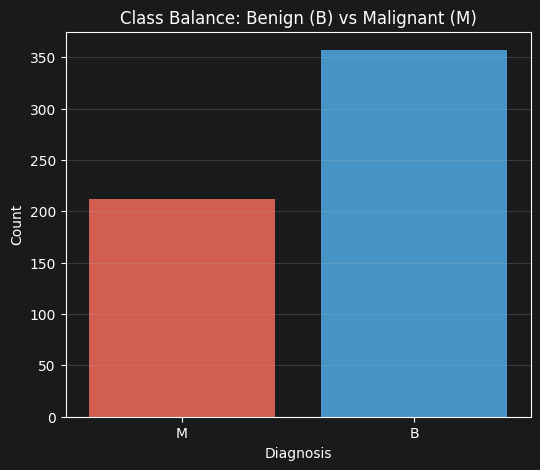

In [4]:
# Visualize the class balance)
plt.figure(figsize=(6, 5))
sns.countplot(data=data, x='diagnosis', palette=['#e74c3c', '#3498db'])
plt.title('Class Balance: Benign (B) vs Malignant (M)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Save the plot to a file
plt.savefig('Fig. 1 - class_balance.png')

# Print counts
counts = data['diagnosis'].value_counts()
print(f"Class Counts:\n{counts}")

The dataset contains 62% benign tumors and 38% malignant tumors. This information is too valuable for the following aspects :
* While splitting the dataset into training and testing sets, this imbalance should be taken into consideration to avoid overfitting.
* The most important metric to evaluate the performance of the model is the **Recall** (Sensitivity).

#### 2.2. Features
As discussed in the first Chapter, we have 30 predicting variables. In the next violin plots, we explore the distribution of each feature per diagnosis.

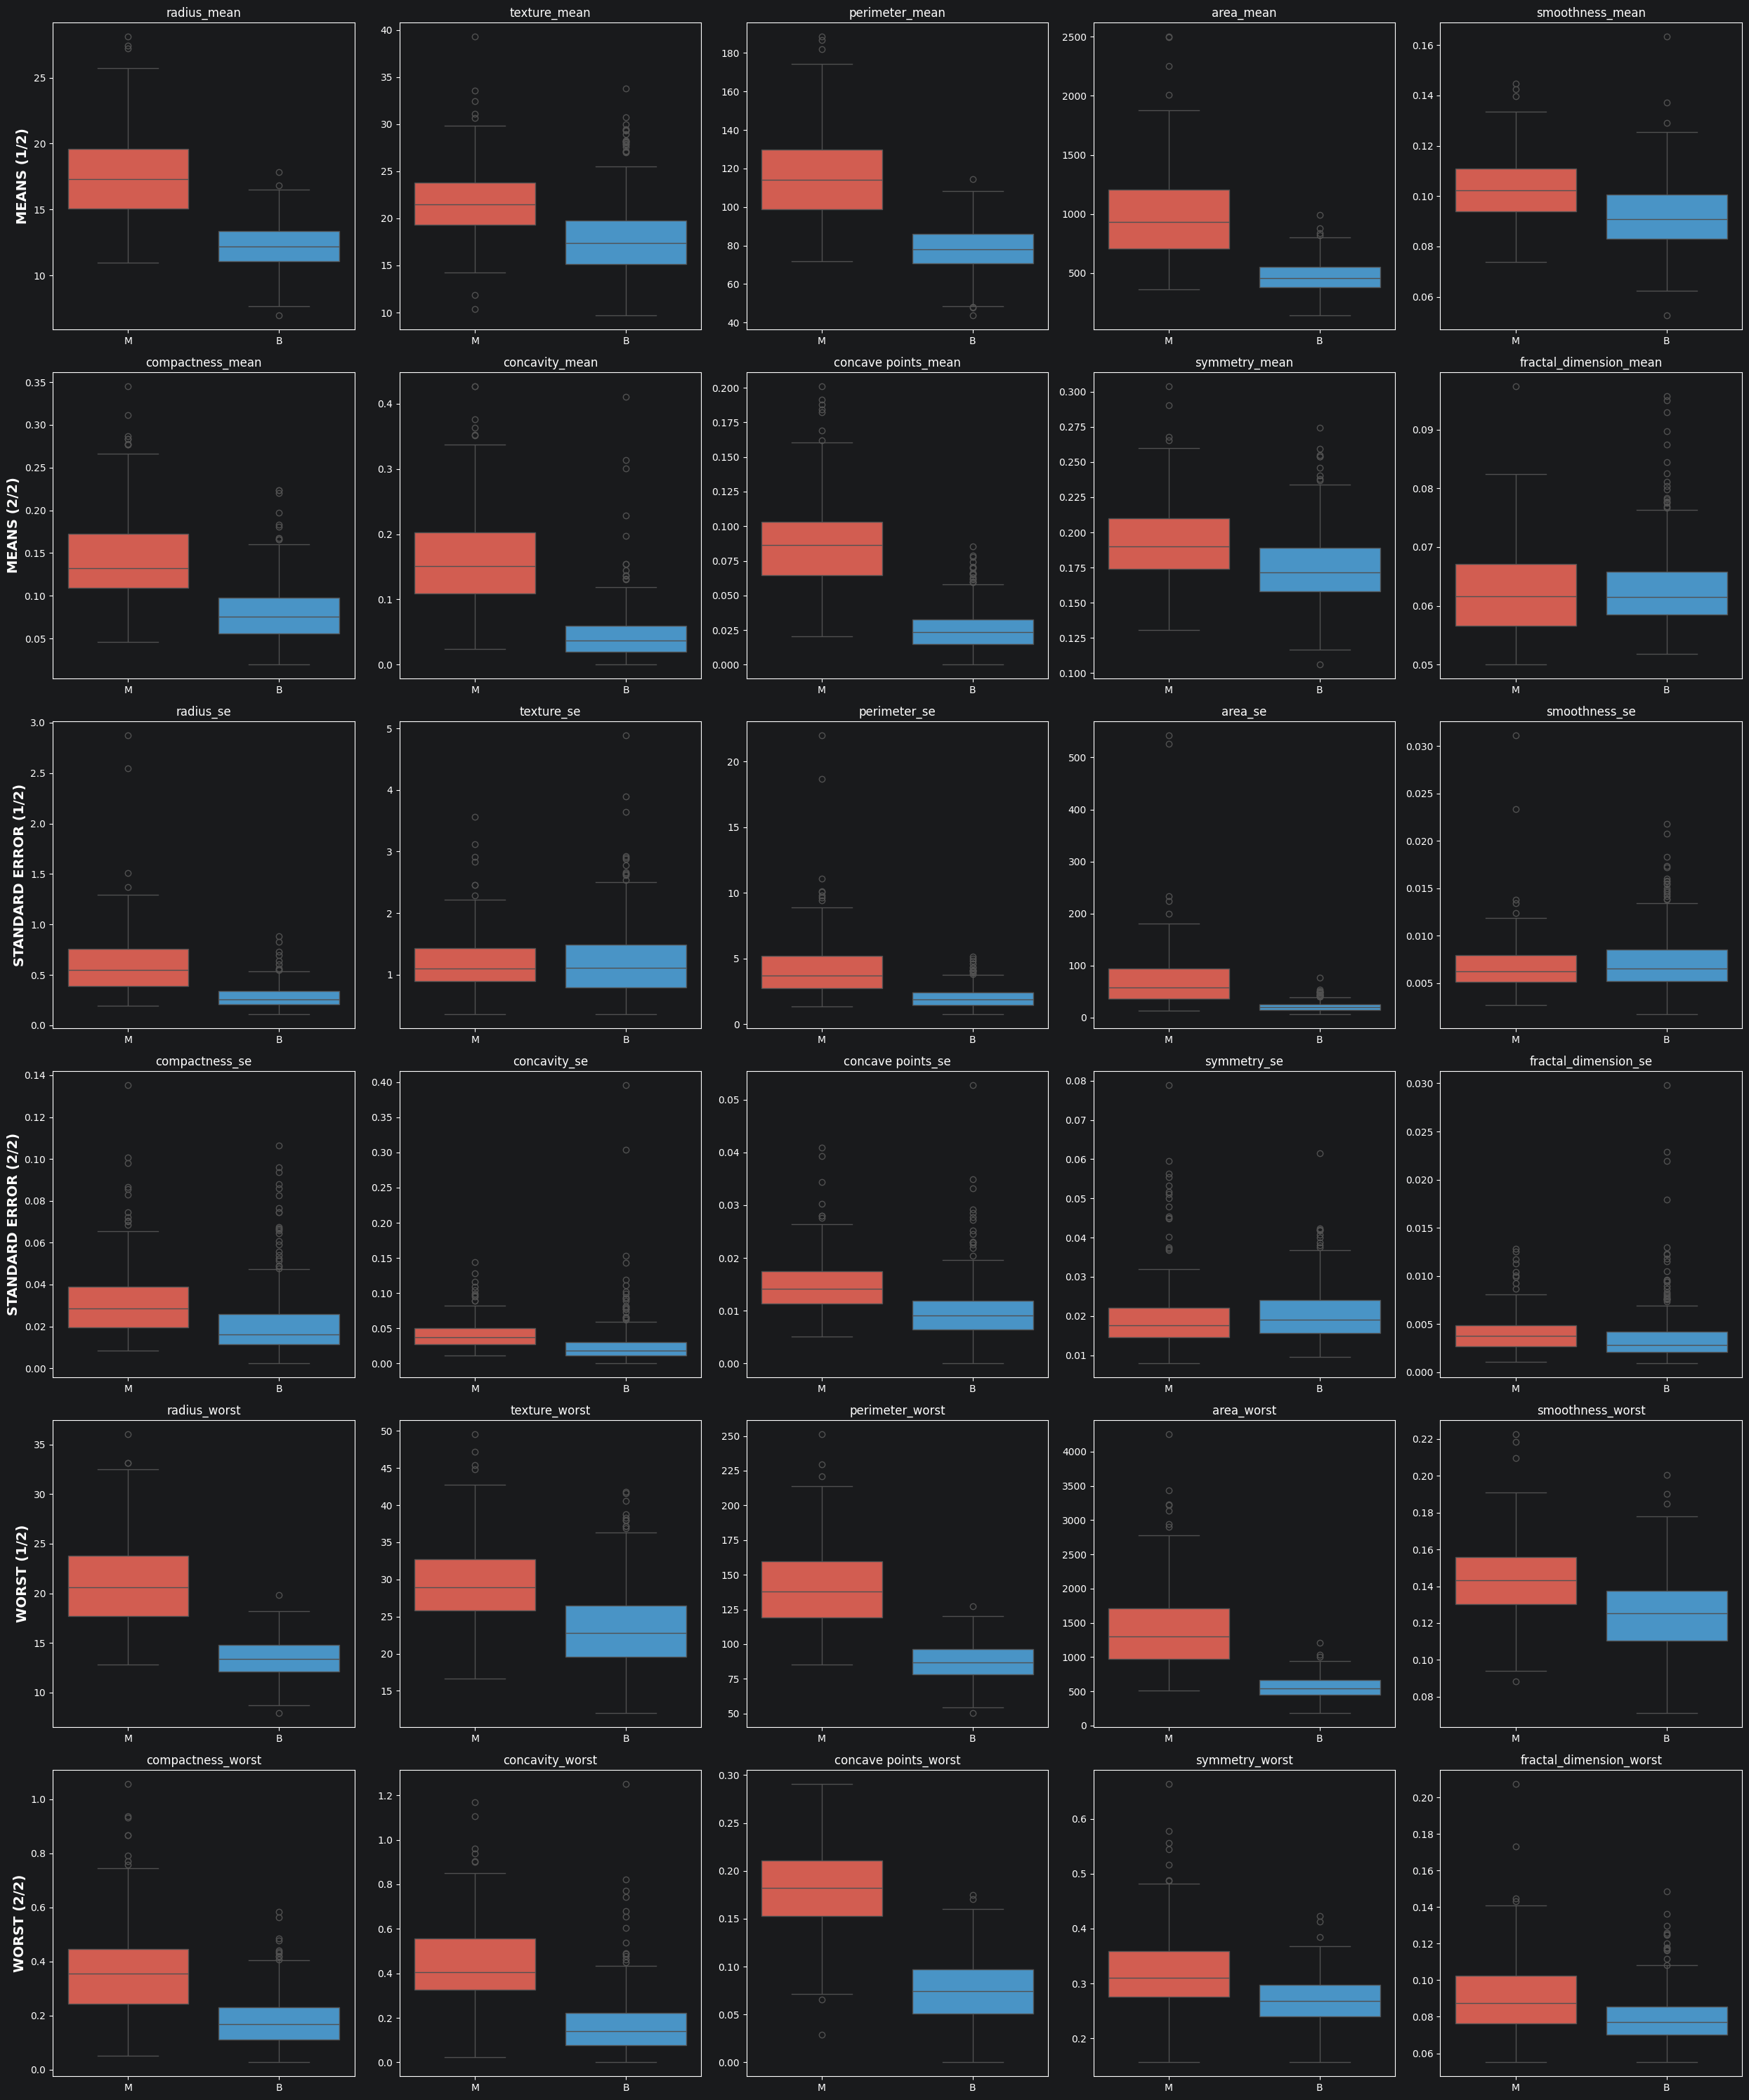

In [5]:
# Define the base features
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension'
]

# Split into two groups for 2-row layout per category
group1 = base_features[:5]
group2 = base_features[5:]

categories = [
    ('_mean', 'MEANS'),
    ('_se', 'STANDARD ERROR'),
    ('_worst', 'WORST')
]

# Total rows = 3 categories * 2 rows per category = 6 rows
# Total columns = 5 features per group
fig, axes = plt.subplots(6, 5, figsize=(25, 30))

current_plot_row = 0

for suffix, cat_name in categories:

    # Plot first 5 features (Row 1 of category)
    for col, feat in enumerate(group1):
        ax = axes[current_plot_row, col]
        sns.boxplot(data=data, x='diagnosis', y=f"{feat}{suffix}", ax=ax, palette=['#e74c3c', '#3498db'])
        ax.set_title(f"{feat}{suffix}", fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if col == 0:
            ax.set_ylabel(f"{cat_name} (1/2)", fontsize=14, fontweight='bold')

    current_plot_row += 1

    # Plot next 5 features (Row 2 of category)
    for col, feat in enumerate(group2):
        ax = axes[current_plot_row, col]
        sns.boxplot(data=data, x='diagnosis', y=f"{feat}{suffix}", ax=ax, palette=['#e74c3c', '#3498db'])
        ax.set_title(f"{feat}{suffix}", fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if col == 0:
            ax.set_ylabel(f"{cat_name} (2/2)", fontsize=14, fontweight='bold')

    current_plot_row += 1

plt.tight_layout()
plt.savefig('Fig. 2 - compact_clinical_violin_grid.png')

Based on these visualizations, we can instantly tell that **Benign cells are more uniformly distributed than malignant cells**.

Furthermore, we can draw the following conclusions :

**1. Chaos translates in Biologically to Malignancy**

The extreme variance observed in the malignant class is not a data collection error; it is the mathematical manifestation of cellular chaos. By preserving these outliers and using a RobustScaler, our model will learn to recognize this biological volatility as a primary predictor of cancer, rather than treating it as statistical noise.

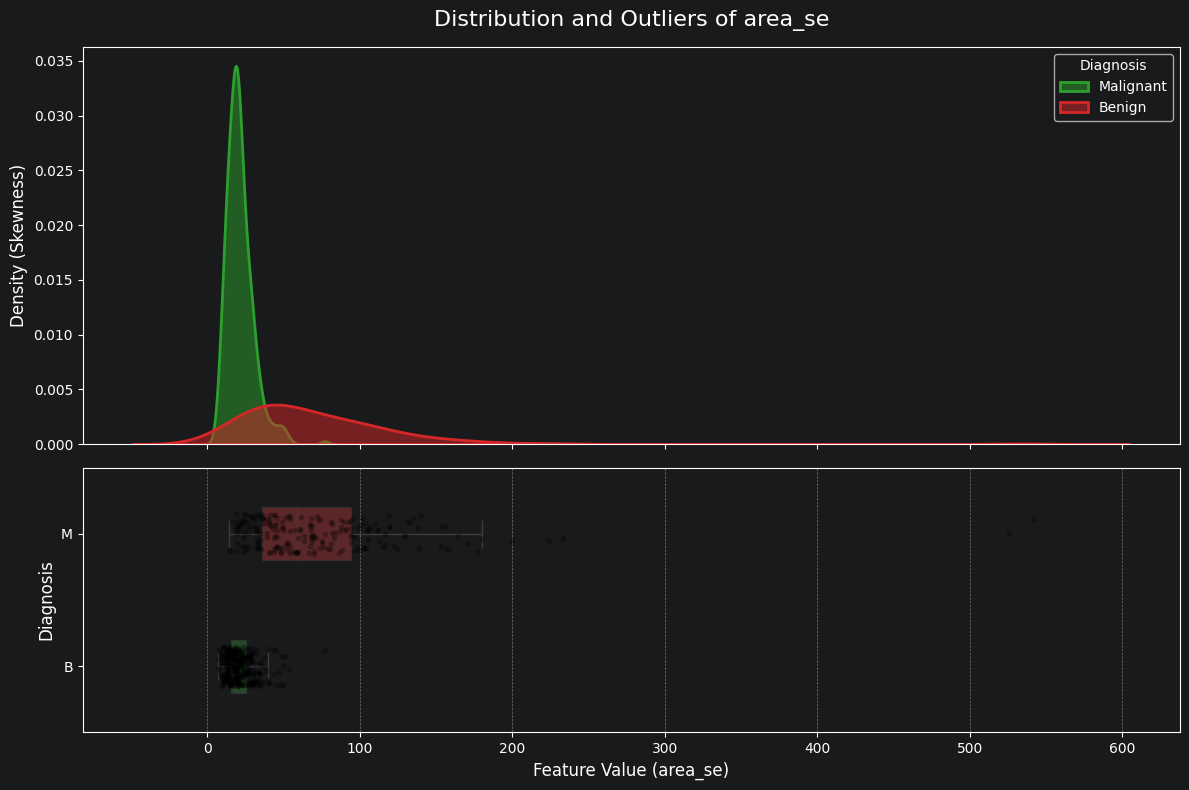

In [6]:
# Choose the single most skewed/interesting feature to highlight
feature_to_plot = 'area_se'

# Create a figure with 2 subplots stacked vertically, sharing the X-axis
fig, (ax_kde, ax_box) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": (.6, .4)} # KDE gets more space
)

# --- 1. The "Cloud" (Density Plot to show Skewness) ---
sns.kdeplot(
    data=data, x=feature_to_plot, hue='diagnosis',
    fill=True, alpha=0.5, linewidth=2, ax=ax_kde,
    palette={'B': '#2ca02c', 'M': '#d62728'}
)
ax_kde.set_title(f'Distribution and Outliers of {feature_to_plot}', fontsize=16, pad=15)
ax_kde.set_ylabel('Density (Skewness)', fontsize=12)
ax_kde.legend(title='Diagnosis', labels=['Malignant', 'Benign']) # Adjust based on your hue order

# --- 2. The "Umbrella & Rain" (Boxplot + Strip Plot for Outliers) ---
sns.boxplot(
    data=data, x=feature_to_plot, y='diagnosis',
    width=0.4, fliersize=0, # Hide default boxplot outliers so they don't double-print
    ax=ax_box, palette={'B': '#2ca02c', 'M': '#d62728'},
    boxprops=dict(alpha=0.4) # Make the boxes slightly transparent
)

# Overlay the actual data points to show the severity of the outliers
sns.stripplot(
    data=data, x=feature_to_plot, y='diagnosis',
    size=4, color="black", alpha=0.3, jitter=0.15, ax=ax_box
)

ax_box.set_xlabel(f'Feature Value ({feature_to_plot})', fontsize=12)
ax_box.set_ylabel('Diagnosis', fontsize=12)
ax_box.grid(axis='x', linestyle='--', alpha=0.6)

# Clean-up layout
plt.tight_layout()
plt.show()

**2. Features Pruning**

While features including *radius_mean*, *perimeter_mean*, and *area_mean* exhibit clear linear separability, validating the use of simple, highly interpretable classification models. Other features like *texture_se* and *smoothness_se* fail to provide information about the diagnosis.

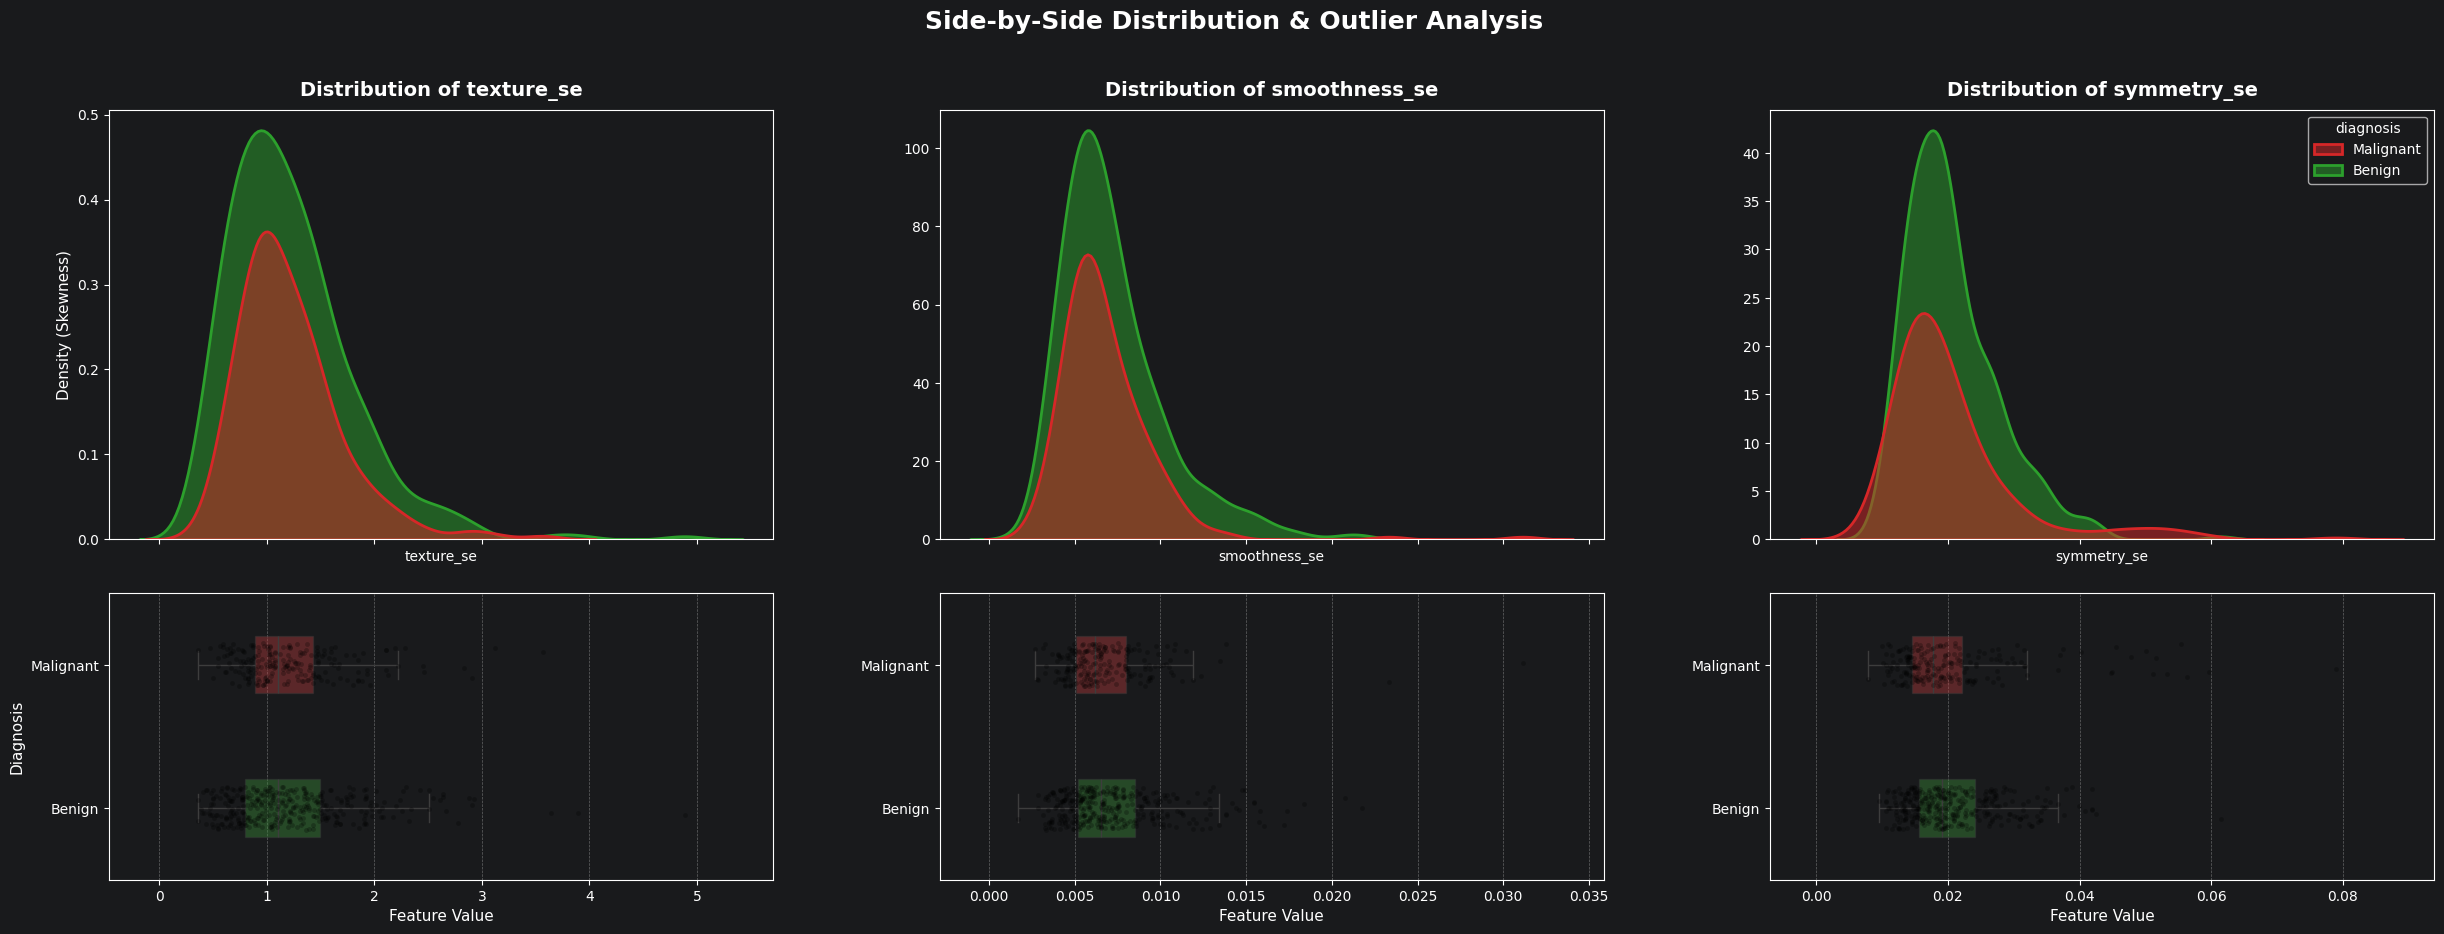

In [15]:
# Define the list of features you want to plot
features_to_plot = ['texture_se', 'smoothness_se', 'symmetry_se']

# Temporarily map the diagnosis column for clean legend and axis titles
data_mapped = data.copy()
data_mapped['diagnosis'] = data_mapped['diagnosis'].map({'M': 'Malignant', 'B': 'Benign'})

# Create a master figure layout (2 rows for KDE/Box, 3 columns for the 3 features)
fig = plt.figure(figsize=(30, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[0.6, 0.4], hspace=0.15, wspace=0.25)

# Generate the subplots dynamically inside the grid
for i, feature in enumerate(features_to_plot):
    # Allocate top and bottom axes for the current column
    ax_kde = fig.add_subplot(gs[0, i])
    ax_box = fig.add_subplot(gs[1, i], sharex=ax_kde) # sharex links the X-axes

    # --- 1. The "Cloud" (Density Plot to show Skewness) ---
    sns.kdeplot(
        data=data_mapped, x=feature, hue='diagnosis',
        hue_order=['Malignant', 'Benign'],
        fill=True, alpha=0.5, linewidth=2, ax=ax_kde,
        palette={'Benign': '#2ca02c', 'Malignant': '#d62728'},
        legend=(i == 2) # Only show the legend on the very last column to avoid clutter
    )
    ax_kde.set_title(f'Distribution of {feature}', fontsize=14, pad=10, fontweight='bold')
    ax_kde.set_ylabel('Density (Skewness)' if i == 0 else '', fontsize=11) # Y-label only on leftmost plot
    ax_kde.tick_params(labelbottom=False) # Hide X-ticks on the top row since they share X

    # --- 2. The "Umbrella & Rain" (Boxplot + Strip Plot for Outliers) ---
    sns.boxplot(
        data=data_mapped, x=feature, y='diagnosis',
        order=['Malignant', 'Benign'],
        width=0.4, fliersize=0,
        ax=ax_box, palette={'Benign': '#2ca02c', 'Malignant': '#d62728'},
        boxprops=dict(alpha=0.4)
    )

    # Overlay the actual data points
    sns.stripplot(
        data=data_mapped, x=feature, y='diagnosis',
        order=['Malignant', 'Benign'],
        size=3.5, color="black", alpha=0.25, jitter=0.15, ax=ax_box
    )

    ax_box.set_xlabel(f'Feature Value', fontsize=11)
    ax_box.set_ylabel('Diagnosis' if i == 0 else '', fontsize=11) # Y-label only on leftmost plot
    ax_box.grid(axis='x', linestyle='--', alpha=0.5)

# Add a grand title for the entire dashboard layout
fig.suptitle('Side-by-Side Distribution & Outlier Analysis', fontsize=18, weight='bold', y=0.98)

plt.show()

**3. Features Correlation**

To minimize model complexity, feature selection was limited strictly to uncorrelated variables.

Top Redundant Feature Pairs (|r| > 0.9):
radius_mean           perimeter_mean         0.997855
perimeter_worst       radius_worst           0.993708
radius_mean           area_mean              0.987357
area_mean             perimeter_mean         0.986507
area_worst            radius_worst           0.984015
perimeter_worst       area_worst             0.977578
perimeter_se          radius_se              0.972794
perimeter_worst       perimeter_mean         0.970387
radius_mean           radius_worst           0.969539
radius_worst          perimeter_mean         0.969476
radius_mean           perimeter_worst        0.965137
radius_worst          area_mean              0.962746
area_worst            area_mean              0.959213
perimeter_worst       area_mean              0.959120
area_se               radius_se              0.951830
area_worst            perimeter_mean         0.941550
radius_mean           area_worst             0.941082
area_se               perimeter_se       

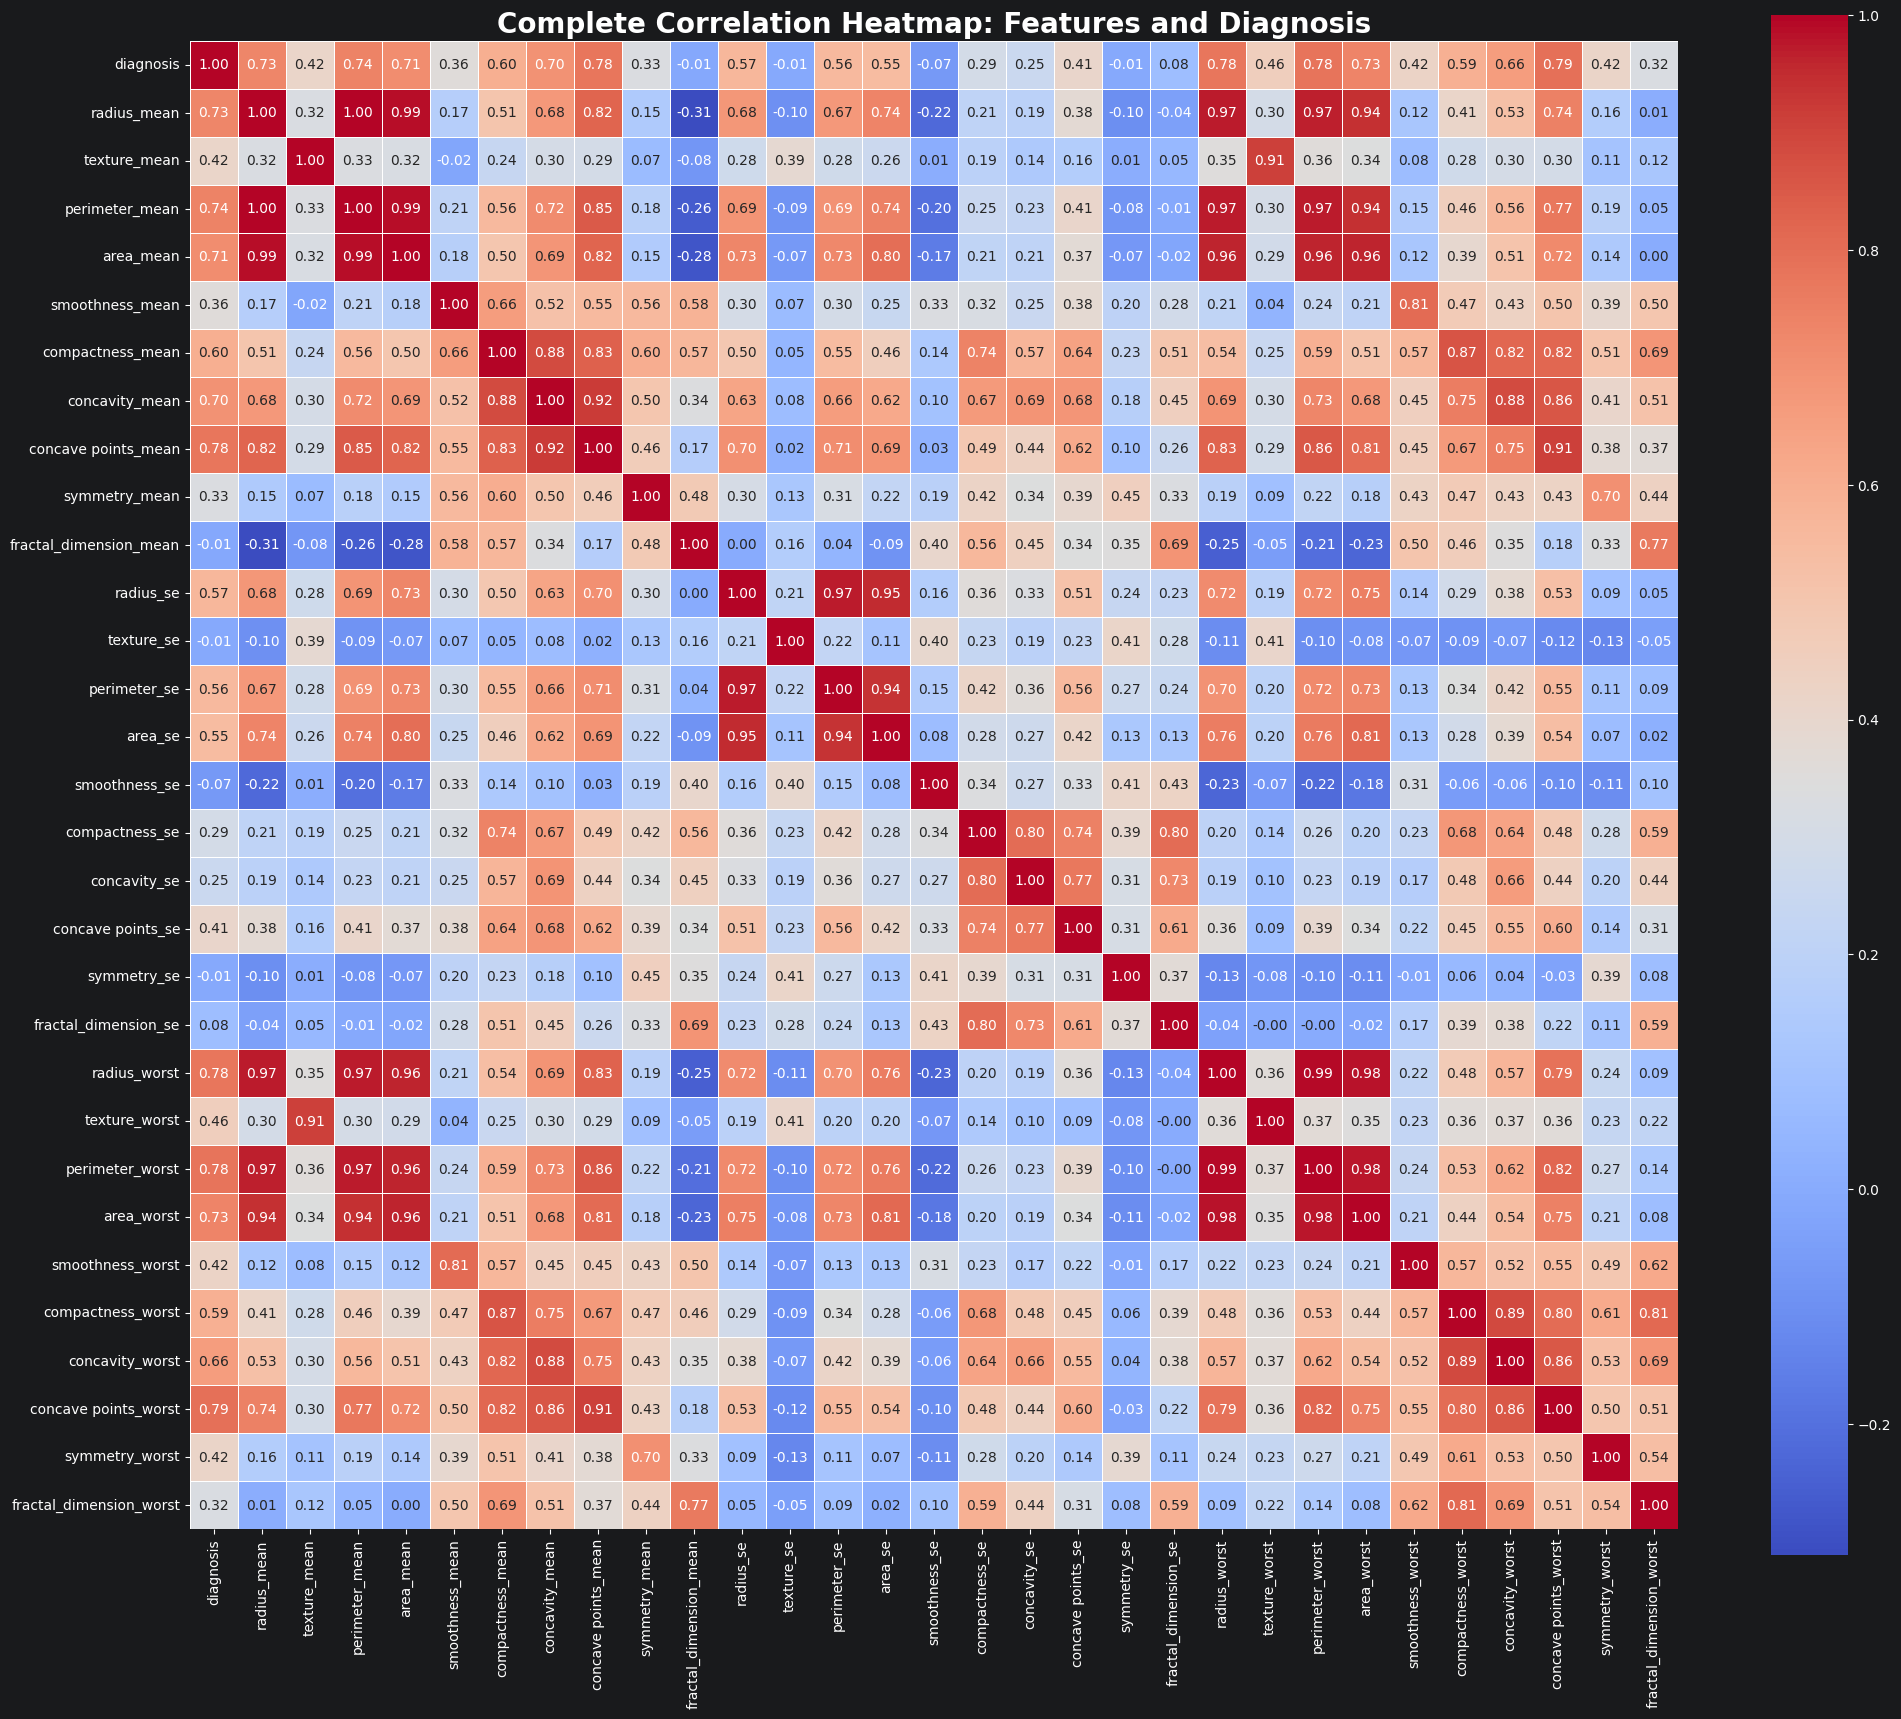

In [13]:
# Drop the non-predictive 'id' column and encode diagnosis for correlation
df_corr = data.drop(columns=['id'])
df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

# Calculate the correlation matrix
corr_matrix = df_corr.corr()

# Create a heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Complete Correlation Heatmap: Features and Diagnosis', fontsize=20, fontweight='bold')
# plt.savefig('complete_correlation_heatmap.png')

# Highlight the most redundant pairs (Correlation > 0.9)
high_corr = corr_matrix.abs().unstack()
high_corr = high_corr.sort_values(ascending=False)

# Remove identity correlations (1.0) and keep unique pairs
redundant_pairs = high_corr[(high_corr > 0.9) & (high_corr < 1.0)].drop_duplicates()

print("Top Redundant Feature Pairs (|r| > 0.9):")
print(redundant_pairs)

### 3. Data Preparation
Subsequently, we move toward applying the techniques discussed in the previous chapters to the data. Starting by transforming the data and encoding the target variable.

In [ ]:
# Encode the target variable
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

Then, we proceed to removing correlated features and feature with no predictive power from the dataset.

In [ ]:
# Drop the non-useful features
features_to_drop = [

    # The redundant perimeter and area metrics (keeping radius foundations)
    'perimeter_mean', 'area_mean', 'perimeter_worst', 'area_worst', 'perimeter_se', 'area_se',

    # Means that clash with more predictive "worst" counterparts
    'radius_mean', 'texture_mean', 'concave points_mean',

    # Features that are not predictive of diagnosis
    'texture_se', 'smoothness_se', 'symmetry_se',

    # Dropping structural shapes outperformed by concave points
    'concavity_mean'
]

# Drop them from your dataframe
data_pre_processed = data.drop(columns=features_to_drop)


# Double-check the reduction
print(f"Original feature count: {data.shape[1]}")
print(f"Cleaned feature count: {data_pre_processed.shape[1]}")

For versioning purposes, the pre processed data ought to be saved.

In [ ]:
# Save the data
data_pre_processed.to_csv(f'{path}/data/data_preprocessed.csv', index=False)

### 4. Modelling
In this phase, we will be training a bunch of models on the data with the final purpose of cross examining their metrics and their interpretability to choose the main model to be used.

#### 4.1. Splitting the Data
The first step is to split the data into training and testing sets. Before that, data preparation covered the most important work of the data. The last touch needed is limited to the use of a scaler right before the split to avoid *Data Leakage*.

*Note*:
> **Data Leakage** occurs when information from outside the training dataset is accidentally used to train a machine learning model, artificially inflating its performance.

> To prevent this, **Feature Scaling (StandardScaler)** is strictly performed *after* the train-test split. The scaler is initialized and fit solely on the training partition (`X_train`) to compute the feature means ($\mu$) and standard deviations ($\sigma$). The test partition (`X_test`) is treated as entirely unseen data and is transformed using those pre-computed training parameters. This architectural choice ensures that the test set remains untainted and provides an unbiased evaluation of the models' real-world generalization capability.

In [ ]:
# X contains all the independent predictors (dropping the target column)
X = data_pre_processed.drop(columns=['diagnosis'])

# y contains only the target variable we want to predict (0 = Benign, 1 = Malignant)
y = data_pre_processed['diagnosis']

# Stratification ensures identical target class distributions across both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# Initiate a Scaler (Standardization)
scaler = StandardScaler()

# Compute mean/std from the training set ONLY, then standardize both partitions
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 4.2. Models Selection
In this section, we will define the models we want to use. 


In [ ]:
# The models are stored as tuples: (Name, Interpretability, Model Object)
models_list = [
    # --- GOOD INTERPRETABILITY (White-Box, Human-Readable Logic) ---
    ('LogisticRegression_L2', 'Good', LogisticRegression(random_state=42, max_iter=1000)),
    ('LogisticRegression', 'Good', LogisticRegression(penalty=None, random_state=42, max_iter=1000)),
    ('DecisionTree_Gini', 'Good', DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)),
    ('DecisionTree_Entropy', 'Good', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)),

    # --- MEDIUM INTERPRETABILITY (Slightly more complex, but still traceable) ---
    ('KNeighbors_K3', 'Medium', KNeighborsClassifier(n_neighbors=3)),
    ('KNeighbors_K7', 'Medium', KNeighborsClassifier(n_neighbors=7)),
    ('LinearDiscriminantAnalysis', 'Medium', LinearDiscriminantAnalysis()),
    ('GaussianNB', 'Medium', GaussianNB()),
    ('RidgeClassifier', 'Medium', RidgeClassifier(random_state=42)),
    ('Perceptron', 'Medium', Perceptron(random_state=42)),

    # --- BAD INTERPRETABILITY (Black-Box / Complex Mathematical Ensembles) ---
    ('RandomForest', 'Bad', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('ExtraTrees', 'Bad', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('BaggingClassifier', 'Bad', BaggingClassifier(random_state=42)),
    ('AdaBoost', 'Bad', AdaBoostClassifier(random_state=42)),
    ('GradientBoosting', 'Bad', GradientBoostingClassifier(random_state=42)),
    ('HistGradientBoosting', 'Bad', HistGradientBoostingClassifier(random_state=42)),
    ('SVC_Linear', 'Bad', SVC(kernel='linear', random_state=42)),
    ('SVC_RBF', 'Bad', SVC(kernel='rbf', random_state=42)),
    ('SVC_Poly', 'Bad', SVC(kernel='poly', degree=3, random_state=42)),
    ('LinearSVC', 'Bad', LinearSVC(max_iter=5000, random_state=42)),
    ('QuadraticDiscriminantAnalysis', 'Bad', QuadraticDiscriminantAnalysis()),
    ('SGDClassifier', 'Bad', SGDClassifier(random_state=42)),
    ('ExtraTreeClassifier', 'Bad', ExtraTreeClassifier(max_depth=5, random_state=42))
]

### 3. Training/Testing
Next, the models created are going to be trained on 70% of the data and tested on the rest.

In [ ]:
# Specifying the train/test data
X_train, X_test, y_train, y_test = train_test_split(
    data[['sound', 'temperature', 'humidity']], data['score'],
    test_size=0.3
)

# Setting a default tracking directory
mlflow.set_tracking_uri(f"file:{path}/mlruns")

# Starting a new experiment
mlflow.create_experiment("Training prospected models")

for model_name, model_instance in models.items():
    # Tagging the experiment (if needed)
    mlflow.set_experiment("Training prospected models")

    # Starting a run
    with mlflow.start_run(run_name=f'Training {model_name}'):
        # Training the model
        model_instance.fit(X_train, y_train)

        # Evaluating the model
        y_estimate = model_instance.predict(X_test)

        # Measuring accuracy of the model
        mse = mean_squared_error(y_test, y_estimate)
        rmse = root_mean_squared_error(y_test, y_estimate)
        mae = mean_absolute_error(y_test, y_estimate)
        r2 = r2_score(y_test, y_estimate)

        # Logging the model
        mlflow.sklearn.log_model(sk_model=model_instance, artifact_path="model",
                                 registered_model_name=model_name)

        # Logging metrics
        mlflow.log_metrics({"MSE": mse, "RMSE": rmse, "MAE": mae, "R-squared": r2})

### 5. Monitoring

For better illustration, a scatter plot is used to provide a visual comparison of the models.

### 6. __Summary__
In this project, 4 models underwent training on fictional data. The models included _Linear Regression_, _Decision Tree_, _Random Forest_, and _Support Vector Machine_.
Upon evaluating these models, it was determined that __Linear Regression__ stood out as the most efficient for the dataset and the preceding visualization effectively depicted the distinctions among the models.

## Author
<a href="https://www.linkedin.com/in/ab0858s/">Abdelali BARIR</a> is a former veteran in the Moroccan's Royal Armed Forces, and a self-taught python programmer. Currently enrolled in B.Sc. Data Science in __IU International University of Applied Sciences__.

## Change Log

| Date         | Version   | Changed By       | Change Description        |
|--------------|-----------|------------------|---------------------------|
| 2024-07-10   | 1.0       | Abdelali Barir   | Modified markdown         |
| ------------ | --------- | ---------------- | ------------------------- |
